In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave_2d/'

datafilename = 'sun_out.nc_0000.nc'
# datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
C = data_.C_int.differentiate("time",datetime_unit="s")
data["C"]=(['time', 'x', 'y'],  C.data)

# Barotropic velocity

In [11]:
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles_2d/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [16]:
Data_ = xr.open_dataset(datafilepath+ 'sun_sparse.nc_0000.nc')
U = np.reshape(Data_.Ubt.data, (len(Data_.time), Nx, Ny), order='F')
V = np.reshape(Data_.Vbt.data, (len(Data_.time), Nx, Ny), order='F')
del Data_

In [23]:
data["U"]=(['time', 'x', 'y'],  U)
data["V"]=(['time', 'x', 'y'],  V)

# scale time

In [6]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# Slope bathymetry & Shoaling depth

In [7]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope
r = width_he2/2+(D0-He/2)/slope
width_base = 2*r

L=1.5*lambdaM2-width_top-(width_base-width_top)/2
W=l_sponge/2

x_c = L/2-(width_base-width_top)/4-width_top/2
y_c = W/2

In [8]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [9]:
x_top = L/2- D0/slope/2 #1.5*lambdaM2/2-width_top-(width_base-width_top)+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

# Plot energy evolution

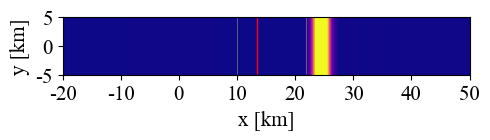

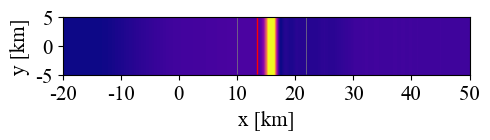

In [18]:
for idx_t in [39, 51]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.8))
    im1 = data_.dEp0[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=5, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    # ax.text(x_c-20000+3000, y_c+1000, f't = {np.round(t_nondim[idx_t],2)}', fontsize=20)
    ax.set_xlim([x_c-20000, x_c+50000])
    ax.set_ylim([y_c-5000, y_c+5000])
    ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
    ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
    ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
    ax.set_yticklabels(['-5','0', '5'])
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEp0_overhead_summer_nof_t{idx_t}_2d.png", transparent = True, dpi=300)

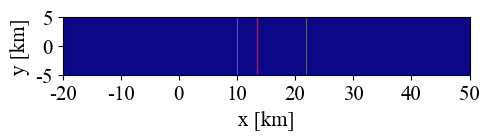

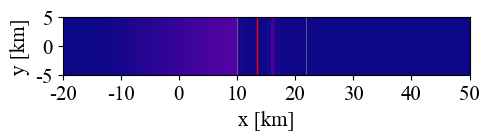

In [19]:
for idx_t in [39, 51]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.8))
    im1 = data_.dEk0[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=5, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    # ax.text(x_c-20000+3000, y_c+1000, f't = {np.round(t_nondim[idx_t],2)}', fontsize=20)
    ax.set_xlim([x_c-20000, x_c+50000])
    ax.set_ylim([y_c-5000, y_c+5000])
    ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
    ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
    ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
    ax.set_yticklabels(['-5','0', '5'])
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEk0_overhead_summer_nof_t{idx_t}_2d.png", transparent = True, dpi=300)

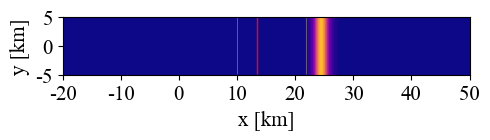

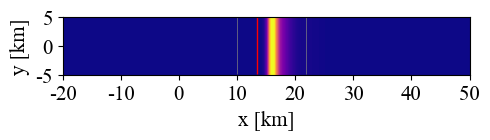

In [20]:
for idx_t in [39, 51]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.8))
    im1 = data_.dEp_prime[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=1e4, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    # ax.text(x_c-20000+3000, y_c+1000, f't = {np.round(t_nondim[idx_t],2)}', fontsize=20)
    ax.set_xlim([x_c-20000, x_c+50000])
    ax.set_ylim([y_c-5000, y_c+5000])
    ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
    ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
    ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
    ax.set_yticklabels(['-5','0', '5'])
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEp_prime_overhead_summer_nof_t{idx_t}_2d.png", transparent = True, dpi=300)

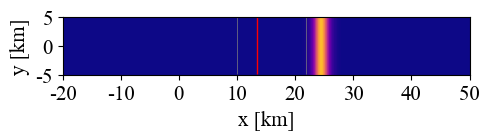

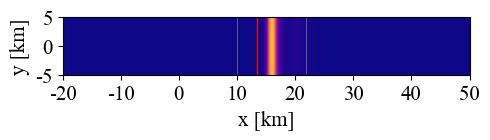

In [21]:
for idx_t in [39, 51]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.8))
    im1 = data_.dEk_prime[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=1e4, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    ax.set_xlim([x_c-20000, x_c+50000])
    ax.set_ylim([y_c-5000, y_c+5000])
    ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
    ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
    ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
    ax.set_yticklabels(['-5','0', '5'])
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEk_prime_overhead_summer_nof_t{idx_t}_2d.png", transparent = True, dpi=300)

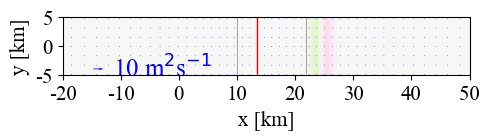

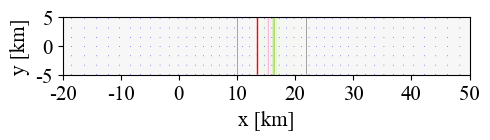

In [27]:
idx_t_ = [13, 17]
count = 0
for idx_t in [39, 51]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.8))
    im1 = (data.C[idx_t,:,:]+data_Cadv.Ah0[idx_t_[count],:,:]).T.plot.pcolormesh(ax=ax, vmax=.05, vmin=-.05, cmap=cm.PiYG_r, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    Q = ax.quiver(data.x.data[::20], data.y.data[::20], (data.U.data[idx_t,::20,::20]*data_.depth[::20,::20].data).T, (data.V.data[idx_t,::20,::20]*data_.depth[::20,::20].data).T, scale=1e2, scale_units='inches', width=2e-3, color='b')
    if count ==0:
        qk = ax.quiverkey(Q, 0.1, .1, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
        
    ax.set_xlim([x_c-20000, x_c+50000])
    ax.set_ylim([y_c-5000, y_c+5000])
    ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
    ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
    ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
    ax.set_yticklabels(['-5','0', '5'])
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    count+=1
    
    plt.savefig(outfilepath+ f"C_overhead_summer_nof_t{idx_t}_2d.png", transparent = True, dpi=300)

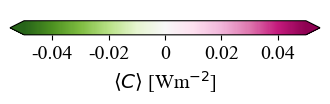

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=.05, vmin=-.05)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.PiYG_r),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(-.04,.04+1e-4,.02), orientation="horizontal")
cbar.ax.set_xticklabels(['-0.04','-0.02','0','0.02','0.04'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle C \rangle$ [Wm$^{-2}$]", size="x-large")
plt.rcParams["font.family"] = "Times New Roman"
ax.axis('off')
plt.savefig(outfilepath+ f"C_colorbar_horizontal.png", transparent = True, dpi=300)


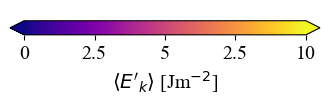

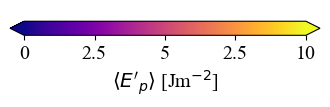

In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=1e4, vmin=0)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.plasma),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(0,1e4+1e-4,2.5e3), orientation="horizontal")
cbar.ax.set_xticklabels(['0','2.5','5','2.5','10'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle E'_k\rangle$ [Jm$^{-2}$]", size='x-large')

ax.axis('off')
plt.savefig(outfilepath+ f"Ek_prime_colorbar_horizontal.png", transparent = True, dpi=300)


fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=1e4, vmin=0)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.plasma),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(0,1e4+1e-4,2.5e3), orientation="horizontal")
cbar.ax.set_xticklabels(['0','2.5','5','2.5','10'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle E'_p\rangle$ [Jm$^{-2}$]", size='x-large')

ax.axis('off')
plt.savefig(outfilepath+ f"Ep_prime_colorbar_horizontal.png", transparent = True, dpi=300)


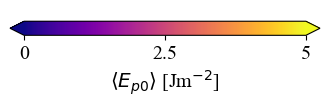

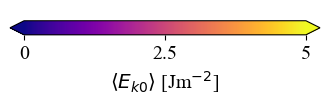

In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=5, vmin=0)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.plasma),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(0,5+1e-4,2.5), orientation="horizontal")
cbar.ax.set_xticklabels(['0','2.5','5'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle E_{p0}\rangle$ [Jm$^{-2}$]", size='x-large')

ax.axis('off')
plt.savefig(outfilepath+ f"Ep0_colorbar_horizontal.png", transparent = True, dpi=300)

fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=5, vmin=0)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.plasma),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(0,5+1e-4,2.5), orientation="horizontal")
cbar.ax.set_xticklabels(['0','2.5','5'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle E_{k0}\rangle$ [Jm$^{-2}$]", size='x-large')

ax.axis('off')
plt.savefig(outfilepath+ f"Ek0_colorbar_horizontal.png", transparent = True, dpi=300)

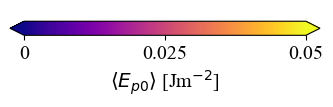

In [31]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 1))

fraction = 1  # .05

norm = mpl.colors.Normalize(vmax=5/100, vmin=0)
cbar = ax.figure.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cm.plasma),
            ax=ax, pad=.15, extend='both', fraction=fraction, 
            ticks=np.arange(0,.05+1e-4,.025), orientation="horizontal")
cbar.ax.set_xticklabels(['0','0.025','0.05'])
cbar.ax.tick_params(labelsize='x-large')
cbar.set_label(label=r"$\langle E_{p0}\rangle$ [Jm$^{-2}$]", size='x-large')

ax.axis('off')
plt.savefig(outfilepath+ f"Ek0_colorbar_horizontal_zoomin.png", transparent = True, dpi=300)